<a href="https://colab.research.google.com/github/Parthwadekar40/ParthCM40-Pattern-Recognition/blob/main/practical_2_PR_Parth40.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fetching dataset from UCI Repository...
Dataset successfully loaded. Features shape: (569, 30)
PCA Variance Explained: PC1=43.69%, PC2=19.23%


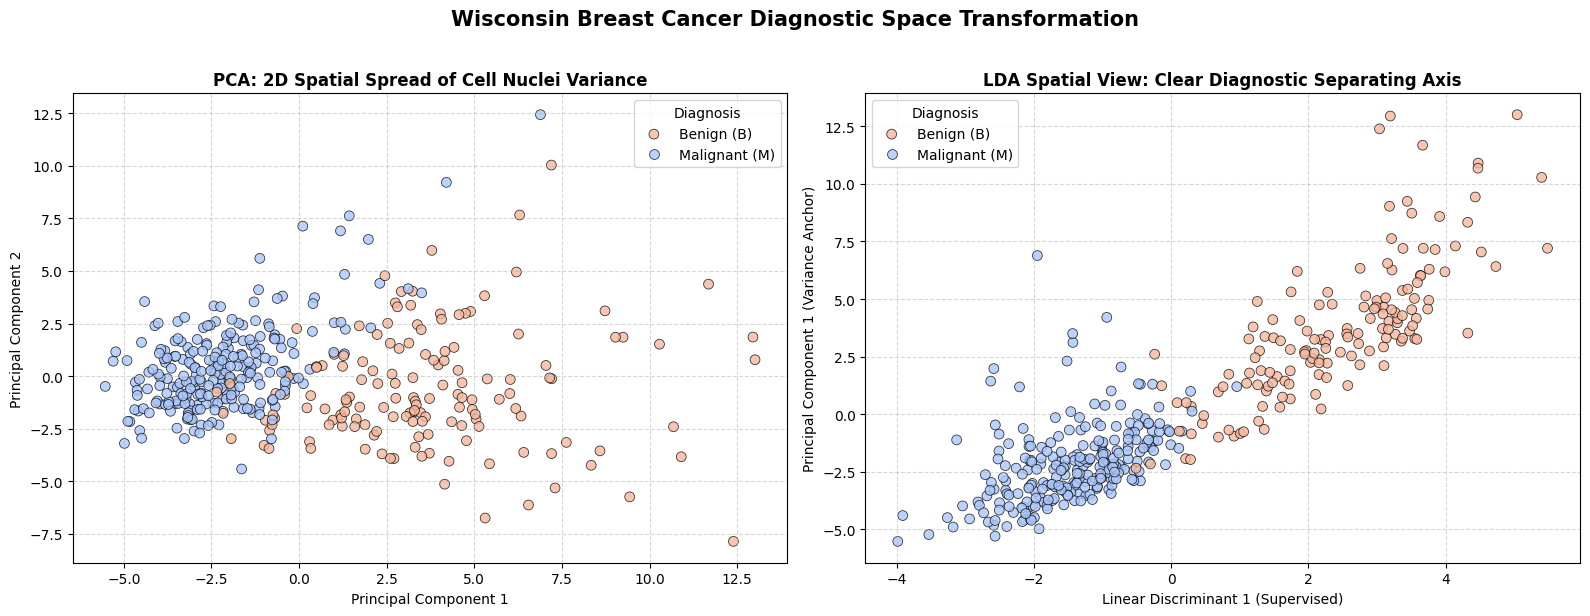


==================== Original Scaled Data (30 Features) Space ====================
Downstream Accuracy: 97.08%
               precision    recall  f1-score   support

   Benign (B)       0.96      0.99      0.98       107
Malignant (M)       0.98      0.94      0.96        64

     accuracy                           0.97       171
    macro avg       0.97      0.96      0.97       171
 weighted avg       0.97      0.97      0.97       171


==================== PCA Reduced Data (2 Components) Space ====================
Downstream Accuracy: 94.15%
               precision    recall  f1-score   support

   Benign (B)       0.92      0.99      0.95       107
Malignant (M)       0.98      0.86      0.92        64

     accuracy                           0.94       171
    macro avg       0.95      0.93      0.94       171
 weighted avg       0.94      0.94      0.94       171


==================== LDA Reduced Data (1 Component) Space ====================
Downstream Accuracy: 98.25%
     

In [4]:
# Install the UCI ML Repository API package
!pip install ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Fetch the Breast Cancer Wisconsin Diagnostic Dataset
print("Fetching dataset from UCI Repository...")
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# Extract features and targets into dataframes
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# Flatten target labels to a 1D array and map to integers (M=1, B=0)
y_encoded = y.values.ravel()
y_numeric = np.where(y_encoded == 'M', 1, 0)
target_names = ['Benign (B)', 'Malignant (M)']

print(f"Dataset successfully loaded. Features shape: {X.shape}")

# 2. Split Data & Apply Standard Scaling
# Scaling is strict for PCA because it is highly sensitive to data variance scales!
X_train, X_test, y_train, y_test = train_test_split(X, y_numeric, test_size=0.3,
                                                    random_state=42, stratify=y_numeric)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Apply Unsupervised PCA (Extract 2 Principal Components)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Calculate explained variance for the report
var_ratio = pca.explained_variance_ratio_
print(f"PCA Variance Explained: PC1={var_ratio[0]:.2%}, PC2={var_ratio[1]:.2%}")

# 4. Apply Supervised LDA (Extract 1 Discriminant Component for Binary Class)
lda = LDA(n_components=1)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

# 5. Advanced Visualizations (PCA 2D Space vs LDA Discriminant Separation)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Standard PCA Scatter Plot
sns.scatterplot(ax=axes[0], x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train,
                palette='coolwarm', alpha=0.8, edgecolor='k', s=50)
axes[0].set_title('PCA: 2D Spatial Spread of Cell Nuclei Variance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].legend(labels=target_names, title="Diagnosis")
axes[0].grid(True, linestyle='--', alpha=0.5)

# Subplot 2: LDA 2D Mapping Plot (Using PC1 as a Y-axis proxy to give LDA depth)
# This prevents a flat 1D line and visualizes the linear separating hyperplane cleanly!
sns.scatterplot(ax=axes[1], x=X_train_lda.ravel(), y=X_train_pca[:, 0], hue=y_train,
                palette='coolwarm', alpha=0.8, edgecolor='k', s=50)
axes[1].set_title('LDA Spatial View: Clear Diagnostic Separating Axis', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Linear Discriminant 1 (Supervised)')
axes[1].set_ylabel('Principal Component 1 (Variance Anchor)')
axes[1].legend(labels=target_names, title="Diagnosis")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Wisconsin Breast Cancer Diagnostic Space Transformation', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 6. Quantifying Performance Improvement
def evaluate_pipeline(X_tr, X_te, space_name):
    # Using Logistic Regression as a standard clinical diagnostic baseline classifier
    clf = LogisticRegression(random_state=42)
    clf.fit(X_tr, y_train)
    preds = clf.predict(X_te)
    acc = accuracy_score(y_test, preds)
    print(f"\n==================== {space_name} Space ====================")
    print(f"Downstream Accuracy: {acc:.2%}")
    print(classification_report(y_test, preds, target_names=target_names))

evaluate_pipeline(X_train_scaled, X_test_scaled, "Original Scaled Data (30 Features)")
evaluate_pipeline(X_train_pca, X_test_pca, "PCA Reduced Data (2 Components)")
evaluate_pipeline(X_train_lda, X_test_lda, "LDA Reduced Data (1 Component)")